# 🔢 2 — Advanced NumPy

**Welcome back!** 🎉 Now that you know the NumPy basics, let's go deeper into the features that make NumPy so powerful for Data Science: **why it's fast**, clever **indexing tricks**, **broadcasting**, and **plotting graphs**.

Every topic is in **simple English**, with **real-life examples** and **line-by-line comments**.

---

## 📚 What you will learn here

| # | Topic |
|---|-------|
| 1 | NumPy vs Python lists (speed, memory, convenience) |
| 2 | Fancy Indexing |
| 3 | Boolean Indexing |
| 4 | **Broadcasting** |
| 5 | Working with mathematical formulas |
| 6 | Handling missing values (`np.nan`) |
| 7 | Plotting graphs with Matplotlib |

---

## 1️⃣ Why is NumPy Better Than Python Lists?

We compare on **three** points: **speed**, **memory**, and **convenience**.

### ⚡ Speed
Let's add two lists of 10 million numbers each — first with a Python loop, then with NumPy.

In [ ]:
# Python lists — add them with a loop
import time
a = [i for i in range(10000000)]
b = [i for i in range(10000000, 20000000)]

c = []
start = time.time()
for i in range(len(a)):
    c.append(a[i] + b[i])
print(time.time() - start, "seconds")

2.8817131519317627 seconds


In [ ]:
# NumPy arrays — add them in one clean operation
import numpy as np
a = np.arange(10000000)
b = np.arange(10000000, 20000000)

start = time.time()
c = a + b
print(time.time() - start, "seconds")

0.6992664337158203 seconds


NumPy was **several times faster**! (Roughly 4× here — the exact ratio varies per machine.)

**Why is NumPy so fast?**
1. It uses a **C-type static array** (fixed size) and stores the values **directly** in memory.
2. A Python list is a **dynamic, referential array** — it stores the *addresses* of items scattered in memory, and resizes by copying. That's slower.

### 🧠 Memory
NumPy uses far less memory — and lets you shrink it further by choosing a smaller data type.

In [ ]:
import sys
a = [i for i in range(10000000)]
sys.getsizeof(a)   # bytes used by the Python list

89095160

In [ ]:
a = np.arange(10000000, dtype=np.int32)   # 32-bit integers
sys.getsizeof(a)

40000112

In [ ]:
a = np.arange(10000000, dtype=np.int8)    # 8-bit integers — tiny!
sys.getsizeof(a)

10000112

😲 The list took ~**89 MB**, but NumPy with `int8` took only ~**10 MB**. If your numbers are small, use a small type and save huge amounts of memory.

### ✨ Convenience
Adding two lists needed a whole loop. In NumPy it was just `a + b`. **NumPy is faster, lighter, AND easier to write.** That's why it's the standard for Data Science.

## 2️⃣ Fancy Indexing

Normal slicing works when there's a **pattern** (like "every 2nd row"). But what if you want rows **1, 3, and 4** — no pattern? Use **fancy indexing**: pass a **list of the indices** you want inside the square brackets.

In [ ]:
a = np.arange(12).reshape(4, 3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11]])

In [ ]:
# grab rows 0, 1, and 3 (no pattern — just list them)
a[[0, 1, 3]]

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 9, 10, 11]])

In [ ]:
a = np.arange(24).reshape(6, 4)
# grab specific COLUMNS: 0, 1, and 2
a[:, [0, 1, 2]]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18],
       [20, 21, 22]])

> 📌 **Rule of thumb:** if the items you want form a *pattern*, use normal slicing. If they **don't** form a pattern, use **fancy indexing** (a list of positions).

## 3️⃣ Boolean Indexing

Sometimes you want items based on a **condition** (e.g. "all numbers greater than 50"), not their position. This is **boolean indexing**.

**How it works:** a comparison like `a > 50` gives a **True/False array (a mask)**. Putting that mask inside `a[...]` keeps only the items where it's `True`.

In [ ]:
# a random 6x4 array (your numbers will differ)
a = np.random.randint(1, 100, 24).reshape(6, 4)
a

array([[40,  8, 63, 39],
       [53, 72, 60, 61],
       [63, 85, 16, 92],
       [79, 82, 47, 12],
       [46, 90, 55, 53],
       [35, 44, 94,  9]])

In [ ]:
a > 50   # a True/False mask

array([[False, False,  True, False],
       [ True,  True,  True,  True],
       [ True,  True, False,  True],
       [ True,  True, False, False],
       [False,  True,  True,  True],
       [False, False,  True, False]])

In [ ]:
a[a > 50]   # keep only the values greater than 50

array([63, 53, 72, 60, 61, 63, 85, 92, 79, 82, 90, 55, 53, 94])

In [ ]:
a[a % 2 == 0]   # keep only the even numbers

array([40,  8, 72, 60, 16, 92, 82, 12, 46, 90, 44, 94])

### Combining conditions
Use **`&`** for AND and **`|`** for OR (with each condition in brackets). ⚠️ Use the bitwise `&`/`|`, **not** the words `and`/`or`.

In [ ]:
# numbers that are greater than 50 AND even
a[(a > 50) & (a % 2 == 0)]

array([72, 60, 92, 82, 90, 94])

> 📌 **Fancy vs Boolean:** *Fancy* indexing picks items by their **position** (a list of indices). *Boolean* indexing filters items by a **condition**.

## 4️⃣ Broadcasting ⭐

**Broadcasting** describes how NumPy handles arithmetic between arrays of **different shapes**. The **smaller** array is automatically "stretched" (broadcast) to match the **larger** one, so the operation can happen — no loops, no manual copying.

### Same shape → easy
When two arrays have the same shape, they combine item-by-item.

In [ ]:
a = np.arange(6).reshape(2, 3)
b = np.arange(6, 12).reshape(2, 3)
print(a + b)

[[ 6  8 10]
 [12 14 16]]


### Different shapes → broadcasting kicks in
Here a `(2,3)` and a `(1,3)` array add just fine — NumPy stretches the smaller one.

In [ ]:
a = np.arange(6).reshape(2, 3)   # shape (2, 3)
b = np.arange(3).reshape(1, 3)   # shape (1, 3)
print(a + b)

[[0 2 4]
 [3 5 7]]


### 🎨 The intuition (diagrams)

*(The original had 3 uploaded diagrams that were lost — here they are as text diagrams.)*

**Example 1:** a `(3,3)` and a `(1,3)`. The single row is **copied downward** to fill 3 rows:
```
   (3,3)            (1,3)              stretched (1,3) → (3,3)
 [ a a a ]         [ x y z ]            [ x y z ]
 [ a a a ]    +                    =    [ x y z ]   → then add
 [ a a a ]                              [ x y z ]
```

**Example 2:** a `(3,1)` and a `(1,3)`. **Both** get stretched to `(3,3)`:
```
  (3,1)          (1,3)              both become (3,3)
 [ p ]          [ x y z ]           [ p p p ]     [ x y z ]
 [ q ]    +                    =    [ q q q ]  +  [ x y z ]
 [ r ]                              [ r r r ]     [ x y z ]
```

NumPy does all this **automatically** — you just write `a + b`.

### 📏 The Broadcasting Rules

NumPy follows these steps to decide if two arrays can be broadcast:

1. **Match the number of dimensions.** If one array has fewer dimensions, add new dimensions of size **1** to the **front** of its shape (e.g. `(3,)` → `(1, 3)`).
2. **Match each dimension's size.** For each dimension, sizes must either be **equal**, or one of them must be **1** (the size-1 dimension gets stretched).
3. **If a dimension's sizes differ and neither is 1 → broadcasting fails** (you get a `ValueError`).

Let's test these rules.

In [ ]:
# ✅ works: (4,3) and (3,) -> the (3,) becomes (1,3) then stretches to (4,3)
a = np.arange(12).reshape(4, 3)
b = np.arange(3)
print(a + b)

[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [ ]:
# ❌ fails: (3,4) and (3,) -> (3,) becomes (1,3), stretches to (3,3), which != (3,4)
a = np.arange(12).reshape(3, 4)
b = np.arange(3)
print(a + b)   # ValueError: operands could not be broadcast together with shapes (3,4) (3,)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[0 1 2]


In [ ]:
# ✅ works: (1,3) and (3,1) -> BOTH stretch to (3,3)
a = np.arange(3).reshape(1, 3)
b = np.arange(3).reshape(3, 1)
print(a + b)

[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [ ]:
# ❌ fails: (3,4) and (4,3) -> no dimension is 1, and the sizes differ
a = np.arange(12).reshape(3, 4)
b = np.arange(12).reshape(4, 3)
print(a + b)   # ValueError: could not be broadcast together with shapes (3,4) (4,3)

## 5️⃣ Working With Mathematical Formulas

NumPy has many built-in maths functions (`np.sum`, `np.sin`, ...). But when you need a formula that *isn't* built-in, you can easily write it yourself — and because of broadcasting, it works on a **whole array** at once.

In [ ]:
# a built-in function
a = np.arange(10)
np.sum(a)

45

### The Sigmoid function
Very famous in Machine Learning (logistic regression). Its formula is:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

We write it once, and it runs on every element of the array.

In [ ]:
def sigmoid(array):
    return 1 / (1 + np.exp(-array))

a = np.arange(10)
sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661])

### Mean Squared Error (MSE)
A famous **loss function** in ML (used in linear regression). It measures how wrong a model's predictions are:

$$MSE = \text{mean}\big((\text{actual} - \text{predicted})^2\big)$$

In [ ]:
def mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)

actual    = np.random.randint(1, 50, 25)
predicted = np.random.randint(1, 50, 25)
mse(actual, predicted)   # your number will differ

315.84

## 6️⃣ Handling Missing Values — `np.nan`

Real datasets often have **missing values**. NumPy represents "missing/not-a-number" with **`np.nan`**. All of NumPy's missing-value tools are built around `np.nan`.

In [ ]:
a = np.array([1, 2, 3, np.nan, 6])   # np.nan is a missing value
a

array([ 1.,  2.,  3., nan,  6.])

**`np.isnan(a)`** asks each item "are you missing?" and returns a True/False mask.

In [ ]:
np.isnan(a)

array([False, False, False,  True, False])

To **remove** the missing values, use the mask with **`~`** (NOT), which flips True↔False — so we keep the values that are *not* missing.

In [ ]:
a[~np.isnan(a)]   # keep everything that is NOT nan

array([1., 2., 3., 6.])

## 7️⃣ Plotting Graphs with Matplotlib

NumPy pairs beautifully with **Matplotlib** to draw graphs. The trick: use **`np.linspace`** to make evenly-spaced `x` values, compute `y` from them, and call `plt.plot(x, y)`.

> 💡 **Tip:** always use `np.linspace` for smooth graphs.

### A straight line: `y = x`

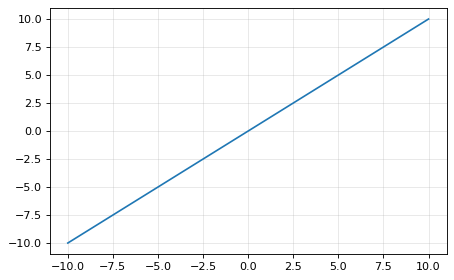

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-10, 10, 100)
y = x
plt.plot(x, y)
plt.show()

### A parabola: `y = x²`

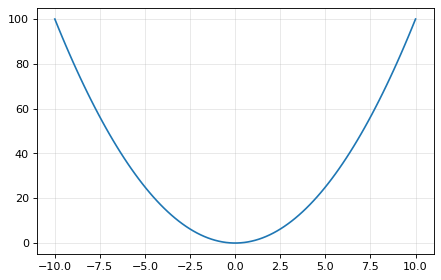

In [ ]:
x = np.linspace(-10, 10, 100)
y = x ** 2
plt.plot(x, y)
plt.show()

### A sine wave: `y = sin(x)`

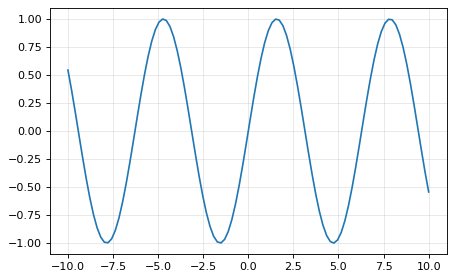

In [ ]:
x = np.linspace(-10, 10, 100)
y = np.sin(x)
plt.plot(x, y)
plt.show()

### The Sigmoid curve: `y = 1 / (1 + e⁻ˣ)`
Notice its famous S-shape — this is why it's so useful in Machine Learning.

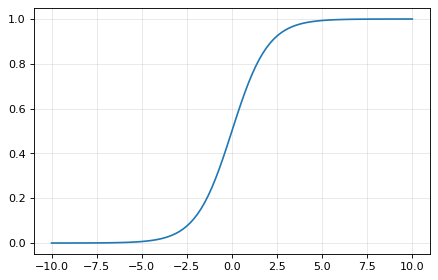

In [ ]:
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))
plt.plot(x, y)
plt.show()

---

## 🎯 Summary — Quick Revision

You now know the *advanced* powers of NumPy! 🎉

| Topic | Key idea |
|-------|----------|
| **Why NumPy** | Faster (C arrays), lighter (small dtypes), easier to write |
| **Fancy indexing** | Pick items by a **list of positions** (no pattern needed) |
| **Boolean indexing** | Filter items by a **condition** (`a[a > 50]`); combine with `&` / `\|` |
| **Broadcasting** | NumPy stretches a smaller array to match a bigger one |
| **Broadcast rules** | Align dimensions; sizes must be equal or 1; else error |
| **Custom formulas** | Write once, runs on the whole array (sigmoid, MSE) |
| **Missing values** | `np.nan`; `np.isnan()`; remove with `a[~np.isnan(a)]` |
| **Plotting** | `np.linspace` + `plt.plot(x, y)` |

---

### 📝 Try It Yourself (Practice Questions)

1. From a random 5×5 array, use fancy indexing to grab rows 0, 2, and 4.
2. From a random array, filter out all numbers **between 30 and 70** (use `&`).
3. Add a `(3,1)` array to a `(1,4)` array and explain the resulting shape.
4. Write a function for the formula `y = x² + 2x + 1` and run it on `np.arange(10)`.
5. Create an array with a few `np.nan` values and replace them with the array's mean.

> 💪 **Remember:** broadcasting and boolean indexing are used *constantly* in real Data Science code. Practise them until they feel natural!

---

**➡️ Next up: 3 — NumPy Tricks.**